## Imports and loading

In [1]:
# ============================================================
# Stroke Prediction Dataset
# Fairness-Aware Loss Function Study
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# ------------------------------------------------------------
# Download dataset directly from Kaggle
# ------------------------------------------------------------

path = kagglehub.dataset_download(
  "fedesoriano/stroke-prediction-dataset"
)

print("Dataset path:", path)

# Show files inside dataset folder
print(os.listdir(path))

# ------------------------------------------------------------
# Load CSV from downloaded Kaggle dataset
# ------------------------------------------------------------

csv_path = os.path.join(
  path,
  "healthcare-dataset-stroke-data.csv"
)

df_raw = pd.read_csv(csv_path)

# ------------------------------------------------------------
# Basic inspection
# ------------------------------------------------------------

print(f"Shape: {df_raw.shape}")
print()

print("Columns:", list(df_raw.columns))
print()

print("Data types:")
print(df_raw.dtypes)
print()

print("First 3 rows:")
print(df_raw.head(3))

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Dataset path: /kaggle/input/stroke-prediction-dataset
['healthcare-dataset-stroke-data.csv']
Shape: (5110, 12)

Columns: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Data types:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

First 3 rows:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0         

In [2]:
# Target distribution

print("Target distribution (stroke):")
print(df_raw["stroke"].value_counts())
print()
print(f"Stroke rate: {df_raw['stroke'].mean():.4f} ({df_raw['stroke'].mean():.1%})")
print()
print("Gender distribution:")
print(df_raw["gender"].value_counts())

Target distribution (stroke):
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke rate: 0.0487 (4.9%)

Gender distribution:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


In [3]:
# Missing Values
print("Missing values per column:")
missing      = df_raw.isnull().sum()
missing_pct  = (missing / len(df_raw) * 100).round(2)
missing_df   = pd.DataFrame({
  "Missing Count": missing,
  "Missing %":     missing_pct
})
print(missing_df[missing_df["Missing Count"] > 0])
print()
print(f"Total missing: {df_raw.isnull().sum().sum()}")

Missing values per column:
     Missing Count  Missing %
bmi            201       3.93

Total missing: 201


In [4]:
# ============================================================
# Clean everything in one aligned block
# Keeps df, y, A perfectly synced throughout
# ============================================================

df = df_raw.copy()

print(f"Starting rows: {len(df)}")

# Step 1 — Drop id column
df = df.drop(columns=["id"])

# Step 2 — Remove "Other" gender (only 1 row)
df = df[df["gender"].isin(["Male", "Female"])].copy()
print(f"After removing 'Other' gender: {len(df)}")

# Step 3 — Handle BMI missing values
# BMI has ~3.9% missing — impute with median
# Dropping is wasteful on a small dataset
bmi_median = df["bmi"].median()
df["bmi"]  = df["bmi"].fillna(bmi_median)
print(f"BMI missing values filled with median: {bmi_median:.2f}")

# Step 4 — Handle smoking_status missing values
# smoking_status has ~30% missing — fill with "Unknown"
# Dropping would lose too many rows on a 5K dataset
df["smoking_status"] = df["smoking_status"].fillna("Unknown")
print(f"Smoking status unknown filled: {(df['smoking_status']=='Unknown').sum()} rows")

# Step 5 — Verify no remaining missing values
assert df.isnull().sum().sum() == 0, "Missing values remain!"
print(f"No missing values remaining ✓")

# Step 6 — Extract sensitive attribute
# Female = 0, Male = 1
A = (df["gender"] == "Male").astype(int).values
df = df.drop(columns=["gender"])

# Step 7 — Extract target
y = df["stroke"].astype(int).values
df = df.drop(columns=["stroke"])

# Step 8 — Reset index
df = df.reset_index(drop=True)

print()
print("=" * 45)
print("FINAL CLEAN DATASET SUMMARY")
print("=" * 45)
print(f"Total rows:     {len(df)}")
print(f"Total features: {df.shape[1]}")
print()
print(f"Target distribution:")
print(f"  Stroke     (1): {y.sum()} ({y.mean():.1%})")
print(f"  No stroke  (0): {(y==0).sum()} ({(1-y.mean()):.1%})")
print()
print(f"Gender distribution:")
print(f"  Male   (1): {(A==1).sum()} ({(A==1).mean():.1%})")
print(f"  Female (0): {(A==0).sum()} ({(A==0).mean():.1%})")

Starting rows: 5110
After removing 'Other' gender: 5109
BMI missing values filled with median: 28.10
Smoking status unknown filled: 1544 rows
No missing values remaining ✓

FINAL CLEAN DATASET SUMMARY
Total rows:     5109
Total features: 9

Target distribution:
  Stroke     (1): 249 (4.9%)
  No stroke  (0): 4860 (95.1%)

Gender distribution:
  Male   (1): 2115 (41.4%)
  Female (0): 2994 (58.6%)


/tmp/ipykernel_16089/2834329710.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stroke_by_age_gender = df_temp.groupby(


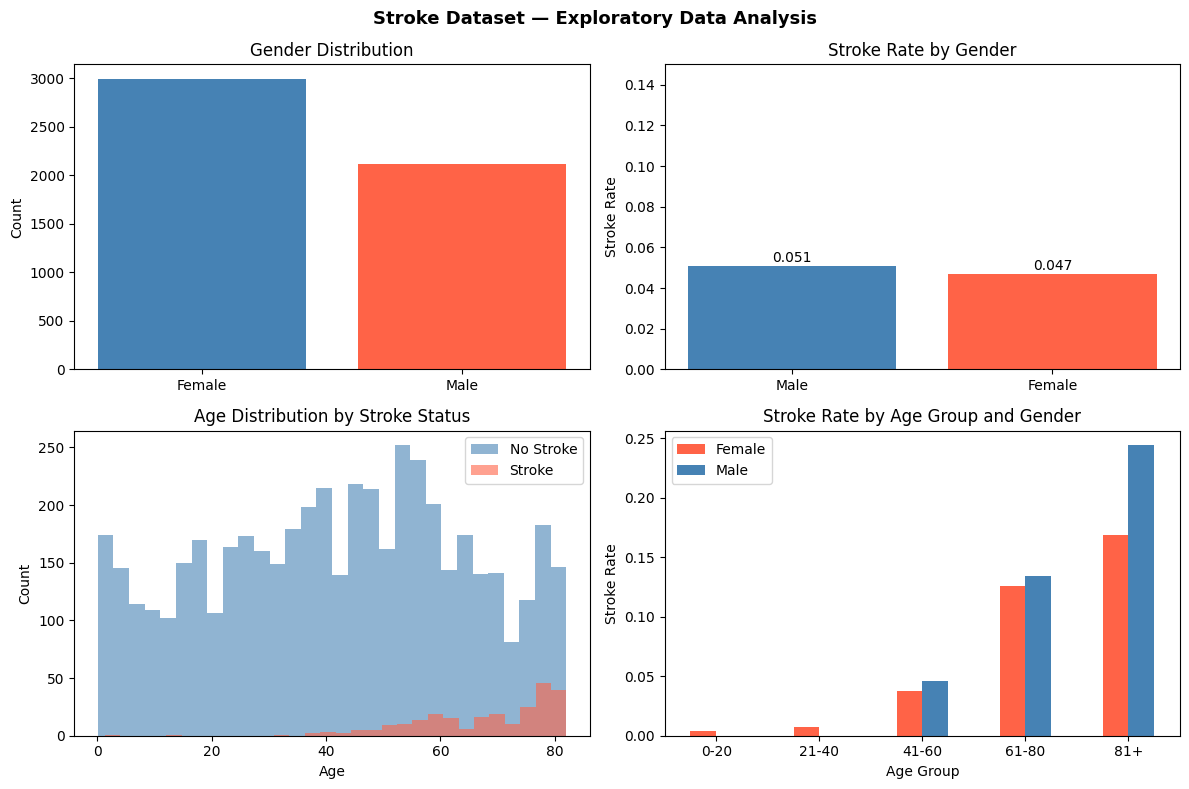


Stroke rate — Male:   0.0511
Stroke rate — Female: 0.0471


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1 — Gender distribution
gender_counts = pd.Series(A).map({0: "Female", 1: "Male"}).value_counts()
axes[0,0].bar(gender_counts.index, gender_counts.values,
            color=["steelblue", "tomato"])
axes[0,0].set_title("Gender Distribution")
axes[0,0].set_ylabel("Count")

# Plot 2 — Stroke rate by gender
stroke_male   = y[A == 1].mean()
stroke_female = y[A == 0].mean()
axes[0,1].bar(["Male", "Female"],
            [stroke_male, stroke_female],
            color=["steelblue", "tomato"])
axes[0,1].set_title("Stroke Rate by Gender")
axes[0,1].set_ylabel("Stroke Rate")
axes[0,1].set_ylim(0, 0.15)
for i, v in enumerate([stroke_male, stroke_female]):
  axes[0,1].text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=10)

# Plot 3 — Age distribution by stroke
axes[1,0].hist(df["age"][y == 0], bins=30, alpha=0.6,
              label="No Stroke", color="steelblue")
axes[1,0].hist(df["age"][y == 1], bins=30, alpha=0.6,
              label="Stroke", color="tomato")
axes[1,0].set_title("Age Distribution by Stroke Status")
axes[1,0].set_xlabel("Age")
axes[1,0].set_ylabel("Count")
axes[1,0].legend()

# Plot 4 — Stroke rate by gender and age group
df_temp        = pd.DataFrame({"age": df["age"], "gender": A, "stroke": y})
df_temp["age_group"] = pd.cut(df_temp["age"],
                            bins=[0,20,40,60,80,100],
                            labels=["0-20","21-40","41-60","61-80","81+"])
stroke_by_age_gender = df_temp.groupby(
  ["age_group","gender"])["stroke"].mean().unstack()
stroke_by_age_gender.columns = ["Female", "Male"]
stroke_by_age_gender.plot(kind="bar", ax=axes[1,1],
                          color=["tomato", "steelblue"])
axes[1,1].set_title("Stroke Rate by Age Group and Gender")
axes[1,1].set_xlabel("Age Group")
axes[1,1].set_ylabel("Stroke Rate")
axes[1,1].tick_params(axis="x", rotation=0)

plt.suptitle("Stroke Dataset — Exploratory Data Analysis",
            fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nStroke rate — Male:   {stroke_male:.4f}")
print(f"Stroke rate — Female: {stroke_female:.4f}")

In [6]:
# One-hot encode categoricals
X_encoded = pd.get_dummies(df, drop_first=True)
X_encoded  = X_encoded.astype(float)

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding:  {X_encoded.shape}")
assert X_encoded.isnull().sum().sum() == 0
print("No missing values ✓")
print()
print("Features after encoding:", list(X_encoded.columns))

Shape before encoding: (5109, 9)
Shape after encoding:  (5109, 14)
No missing values ✓

Features after encoding: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [7]:
# ============================================================
# DIAGNOSTIC PROPERTIES — BRD and PCS
# ============================================================

rate_male   = y[A == 1].mean()
rate_female = y[A == 0].mean()
BRD         = abs(rate_male - rate_female)

n_female_positive = ((A == 0) & (y == 1)).sum()
PCS               = n_female_positive / len(y)

print("=" * 50)
print("DATASET DIAGNOSTIC PROPERTIES")
print("=" * 50)
print(f"Stroke rate — Male:           {rate_male:.4f}")
print(f"Stroke rate — Female:         {rate_female:.4f}")
print(f"Base Rate Disparity (BRD):    {BRD:.4f}")
print(f"Positive Class Sparsity (PCS):{PCS:.4f}")
print()
print("Interpretation:")
print(f"  BRD={BRD:.3f} — "
    f"{'HIGH' if BRD > 0.2 else 'MODERATE' if BRD > 0.1 else 'LOW'}"
    f" base rate gap between groups")
print(f"  PCS={PCS:.3f} — "
    f"{'SPARSE' if PCS < 0.05 else 'MODERATE' if PCS < 0.15 else 'SUFFICIENT'}"
    f" positive class minority representation")
print()

# Pre-training prediction
print("=" * 50)
print("PRE-TRAINING FAIRNESS PREDICTION")
print("=" * 50)

if PCS < 0.05:
  dp_pred = "LIKELY TO FAIL"
  eo_pred = "WILL FAIL"
  reason  = "PCS too sparse — minority gradient signal near zero"
elif BRD > 0.25 and PCS < 0.10:
  dp_pred = "PARTIAL — needs high λ with accuracy cost"
  eo_pred = "MARGINAL — weak gradient signal"
  reason  = "High BRD creates gradient conflict, moderate PCS limits EO"
elif BRD > 0.10 and PCS >= 0.05:
  dp_pred = "PARTIAL — moderate gradient conflict expected"
  eo_pred = "VIABLE — sufficient positive class signal"
  reason  = "Moderate BRD with sufficient PCS"
else:
  dp_pred = "LIKELY VIABLE — low gradient conflict"
  eo_pred = "VIABLE — strong positive class signal"
  reason  = "Low BRD and sufficient PCS — favorable conditions"

print(f"Predicted DP effectiveness: {dp_pred}")
print(f"Predicted EO effectiveness: {eo_pred}")
print(f"Reason: {reason}")
print()
print("We will validate this prediction after training.")

DATASET DIAGNOSTIC PROPERTIES
Stroke rate — Male:           0.0511
Stroke rate — Female:         0.0471
Base Rate Disparity (BRD):    0.0040
Positive Class Sparsity (PCS):0.0276

Interpretation:
  BRD=0.004 — LOW base rate gap between groups
  PCS=0.028 — SPARSE positive class minority representation

PRE-TRAINING FAIRNESS PREDICTION
Predicted DP effectiveness: LIKELY TO FAIL
Predicted EO effectiveness: WILL FAIL
Reason: PCS too sparse — minority gradient signal near zero

We will validate this prediction after training.


In [8]:
# Train/test split — stratified
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
  X_encoded.values, y, A,
  test_size=0.2,
  random_state=42,
  stratify=y
)

# Scale
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float64)
X_test_scaled  = scaler.transform(X_test).astype(np.float64)

y_train = y_train.astype(np.float64)
y_test  = y_test.astype(np.float64)
A_train = A_train.astype(np.float64)
A_test  = A_test.astype(np.float64)

print(f"Train: {X_train_scaled.shape}")
print(f"Test:  {X_test_scaled.shape}")
print(f"Train positive rate: {y_train.mean():.4f}")
print(f"Test positive rate:  {y_test.mean():.4f}")
print()

# Class weights — stroke is rare (~4.9%)
n_total    = len(y_train)
n_positive = y_train.sum()
n_negative = n_total - n_positive

w_positive = n_total / (2 * n_positive)
w_negative = n_total / (2 * n_negative)

sample_weights = np.where(y_train == 1, w_positive, w_negative)

print(f"Positive weight: {w_positive:.4f}")
print(f"Negative weight: {w_negative:.4f}")
print(f"Mean weight:     {sample_weights.mean():.4f}")

Train: (4087, 14)
Test:  (1022, 14)
Train positive rate: 0.0487
Test positive rate:  0.0489

Positive weight: 10.2688
Negative weight: 0.5256
Mean weight:     1.0000


In [9]:
# Sklearn baseline with class weights
model = LogisticRegression(
  max_iter=1000,
  random_state=42,
  class_weight="balanced"
)
model.fit(X_train_scaled, y_train)

y_pred_sk = model.predict(X_test_scaled)
y_prob_sk  = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred_sk)
auc = roc_auc_score(y_test, y_prob_sk)

# DP
dp_male   = np.mean(y_pred_sk[A_test == 1])
dp_female = np.mean(y_pred_sk[A_test == 0])
dp_diff   = abs(dp_male - dp_female)

# EO
male_pos   = (y_test == 1) & (A_test == 1)
female_pos = (y_test == 1) & (A_test == 0)
tpr_male   = np.sum(y_pred_sk[male_pos]   == 1) / max(np.sum(male_pos),   1)
tpr_female = np.sum(y_pred_sk[female_pos] == 1) / max(np.sum(female_pos), 1)
eo_diff    = abs(tpr_male - tpr_female)

print("=" * 45)
print("SKLEARN BASELINE (class_weight=balanced)")
print("=" * 45)
print(f"Accuracy: {acc:.4f}")
print(f"AUC:      {auc:.4f}")
print(f"DP Diff:  {dp_diff:.4f} (M={dp_male:.4f}, F={dp_female:.4f})")
print(f"EO Diff:  {eo_diff:.4f} (TPR_M={tpr_male:.4f}, TPR_F={tpr_female:.4f})")
print()
print("NOTE: AUC is primary metric due to class imbalance")
print(f"      (stroke rate only {y.mean():.1%})")

SKLEARN BASELINE (class_weight=balanced)
Accuracy: 0.7290
AUC:      0.8391
DP Diff:  0.0215 (M=0.3129, F=0.2915)
EO Diff:  0.0657 (TPR_M=0.7619, TPR_F=0.8276)

NOTE: AUC is primary metric due to class imbalance
      (stroke rate only 4.9%)


## Training

In [10]:
# ============================================================
# Helper Functions — copy from Diabetes notebook
# Weighted versions for class imbalance
# ============================================================

def sigmoid(z):
  z = np.clip(z, -500, 500)
  return 1 / (1 + np.exp(-z))

def initialize_params(n_features):
  return np.zeros(n_features), 0

def predict_proba(X, w, b):
  return sigmoid(np.dot(X, w) + b)

def compute_log_loss_weighted(y, y_hat, weights):
  eps   = 1e-15
  y_hat = np.clip(y_hat, eps, 1 - eps)
  losses = -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
  return np.mean(weights * losses)

def compute_gradients_weighted(X, y, y_hat, weights):
  m         = len(y)
  residuals = (y_hat - y) * weights
  dw        = (1/m) * np.dot(X.T, residuals)
  db        = (1/m) * np.sum(residuals)
  return dw, db

def compute_dp_penalty(y_hat, A):
  G0 = (A == 0)
  G1 = (A == 1)
  if np.sum(G0) == 0 or np.sum(G1) == 0:
    return 0
  return (np.mean(y_hat[G0]) - np.mean(y_hat[G1])) ** 2

def compute_dp_gradients(X, y_hat, A):
  G0     = (A == 0)
  G1     = (A == 1)
  n0, n1 = np.sum(G0), np.sum(G1)
  if n0 == 0 or n1 == 0:
    return np.zeros(X.shape[1]), 0
  diff = np.mean(y_hat[G0]) - np.mean(y_hat[G1])
  dw   = np.zeros(X.shape[1])
  for i in range(len(y_hat)):
    if A[i] == 0:
      dw += diff * X[i] / n0
    else:
      dw -= diff * X[i] / n1
  dw /= len(y_hat)
  return dw, diff

def compute_eo_penalty(y_hat, y, A):
  mask_pos = (y == 1)
  G0       = (A == 0) & mask_pos
  G1       = (A == 1) & mask_pos
  if np.sum(G0) == 0 or np.sum(G1) == 0:
    return 0
  return (np.mean(y_hat[G0]) - np.mean(y_hat[G1])) ** 2

def compute_eo_gradients(X, y_hat, y, A):
  mask_pos = (y == 1)
  G0       = (A == 0) & mask_pos
  G1       = (A == 1) & mask_pos
  n0, n1   = np.sum(G0), np.sum(G1)
  if n0 == 0 or n1 == 0:
    return np.zeros(X.shape[1]), 0
  diff = np.mean(y_hat[G0]) - np.mean(y_hat[G1])
  dw   = np.zeros(X.shape[1])
  for i in range(len(y_hat)):
    if not mask_pos[i]:
      continue
    if A[i] == 0:
      dw += diff * X[i] / n0
    else:
      dw -= diff * X[i] / n1
  dw /= len(y_hat)
  return dw, diff

def demographic_parity_difference(y_pred, A):
  dp0 = np.mean(y_pred[A == 0])
  dp1 = np.mean(y_pred[A == 1])
  return abs(dp1 - dp0), dp0, dp1

def equal_opportunity_difference(y_true, y_pred, A):
  male_pos   = (y_true == 1) & (A == 1)
  female_pos = (y_true == 1) & (A == 0)
  tpr_male   = np.sum(y_pred[male_pos]   == 1) / max(np.sum(male_pos),   1)
  tpr_female = np.sum(y_pred[female_pos] == 1) / max(np.sum(female_pos), 1)
  return abs(tpr_male - tpr_female), tpr_male, tpr_female

def train_fair_model_weighted(
  X_train, y_train, A_train, sample_weights,
  lr=0.01, epochs=50,
  lambda_val=0, fairness_type=None
):
  w, b             = initialize_params(X_train.shape[1])
  loss_history     = []
  fairness_history = []

  for epoch in range(epochs):
    y_hat  = predict_proba(X_train, w, b)
    L_pred = compute_log_loss_weighted(y_train, y_hat, sample_weights)

    if fairness_type == "dp":
      R          = compute_dp_penalty(y_hat, A_train)
      dw_f, db_f = compute_dp_gradients(X_train, y_hat, A_train)
    elif fairness_type == "eo":
      R          = compute_eo_penalty(y_hat, y_train, A_train)
      dw_f, db_f = compute_eo_gradients(
        X_train, y_hat, y_train, A_train)
    else:
      R    = 0
      dw_f = np.zeros_like(w)
      db_f = 0

    L_total          = L_pred + lambda_val * R
    dw_pred, db_pred = compute_gradients_weighted(
      X_train, y_train, y_hat, sample_weights)

    w -= lr * (dw_pred + lambda_val * dw_f)
    b -= lr * (db_pred + lambda_val * db_f)

    loss_history.append(L_total)
    fairness_history.append(R)

    if epoch % 10 == 0:
      print(f"Epoch {epoch}: Loss={L_pred:.4f}, "
          f"Fairness={R:.8f}")

  print(f"Final Epoch {epoch}: Loss={L_pred:.4f}, "
      f"Fairness={R:.8f}")
  return w, b, loss_history, fairness_history

print("All helper functions loaded.")

All helper functions loaded.


In [11]:
# ============================================================
# Learning Rate Selection — Stroke Dataset
# Small dataset (4087 train) — similar to Heart Disease
# Start with similar LR range
# ============================================================

learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
lr_results     = {}

for lr in learning_rates:
  w, b, loss_hist, _ = train_fair_model_weighted(
    X_train_scaled, y_train, A_train, sample_weights,
    lr=lr, epochs=50,
    lambda_val=0, fairness_type=None
  )
  y_prob = predict_proba(X_test_scaled, w, b)
  y_pred = (y_prob >= 0.5).astype(int)
  acc    = np.mean(y_pred == y_test)
  auc    = roc_auc_score(y_test, y_prob)
  pred_pos_rate = y_pred.mean()

  lr_results[lr] = {
    "loss_history":       loss_hist,
    "accuracy":           acc,
    "auc":                auc,
    "final_loss":         loss_hist[-1],
    "pred_positive_rate": pred_pos_rate
  }
  print(f"LR={lr:.3f} | Loss={loss_hist[-1]:.4f} | "
      f"Acc={acc:.4f} | AUC={auc:.4f} | "
      f"Pred pos rate={pred_pos_rate:.3f}")

Epoch 0: Loss=0.6931, Fairness=0.00000000
Epoch 10: Loss=0.6913, Fairness=0.00000000
Epoch 20: Loss=0.6894, Fairness=0.00000000
Epoch 30: Loss=0.6876, Fairness=0.00000000
Epoch 40: Loss=0.6859, Fairness=0.00000000
Final Epoch 49: Loss=0.6843, Fairness=0.00000000
LR=0.001 | Loss=0.6843 | Acc=0.5421 | AUC=0.8050 | Pred pos rate=0.495
Epoch 0: Loss=0.6931, Fairness=0.00000000
Epoch 10: Loss=0.6841, Fairness=0.00000000
Epoch 20: Loss=0.6757, Fairness=0.00000000
Epoch 30: Loss=0.6680, Fairness=0.00000000
Epoch 40: Loss=0.6609, Fairness=0.00000000
Final Epoch 49: Loss=0.6550, Fairness=0.00000000
LR=0.005 | Loss=0.6550 | Acc=0.5470 | AUC=0.8059 | Pred pos rate=0.490
Epoch 0: Loss=0.6931, Fairness=0.00000000
Epoch 10: Loss=0.6757, Fairness=0.00000000
Epoch 20: Loss=0.6609, Fairness=0.00000000
Epoch 30: Loss=0.6482, Fairness=0.00000000
Epoch 40: Loss=0.6373, Fairness=0.00000000
Final Epoch 49: Loss=0.6288, Fairness=0.00000000
LR=0.010 | Loss=0.6288 | Acc=0.5519 | AUC=0.8073 | Pred pos rate=0.48

Epoch 0: Loss=0.6931, Fairness=0.00000000
Epoch 10: Loss=0.5006, Fairness=0.00000000
Epoch 20: Loss=0.4812, Fairness=0.00000000
Epoch 30: Loss=0.4745, Fairness=0.00000000
Epoch 40: Loss=0.4717, Fairness=0.00000000
Final Epoch 49: Loss=0.4704, Fairness=0.00000000
Epochs=  50 | Final Loss: 0.4704
Epoch 0: Loss=0.6931, Fairness=0.00000000
Epoch 10: Loss=0.5006, Fairness=0.00000000
Epoch 20: Loss=0.4812, Fairness=0.00000000
Epoch 30: Loss=0.4745, Fairness=0.00000000
Epoch 40: Loss=0.4717, Fairness=0.00000000
Epoch 50: Loss=0.4703, Fairness=0.00000000
Epoch 60: Loss=0.4697, Fairness=0.00000000
Epoch 70: Loss=0.4693, Fairness=0.00000000
Epoch 80: Loss=0.4691, Fairness=0.00000000
Epoch 90: Loss=0.4690, Fairness=0.00000000
Final Epoch 99: Loss=0.4689, Fairness=0.00000000
Epochs= 100 | Final Loss: 0.4689
Epoch 0: Loss=0.6931, Fairness=0.00000000
Epoch 10: Loss=0.5006, Fairness=0.00000000
Epoch 20: Loss=0.4812, Fairness=0.00000000
Epoch 30: Loss=0.4745, Fairness=0.00000000
Epoch 40: Loss=0.4717,

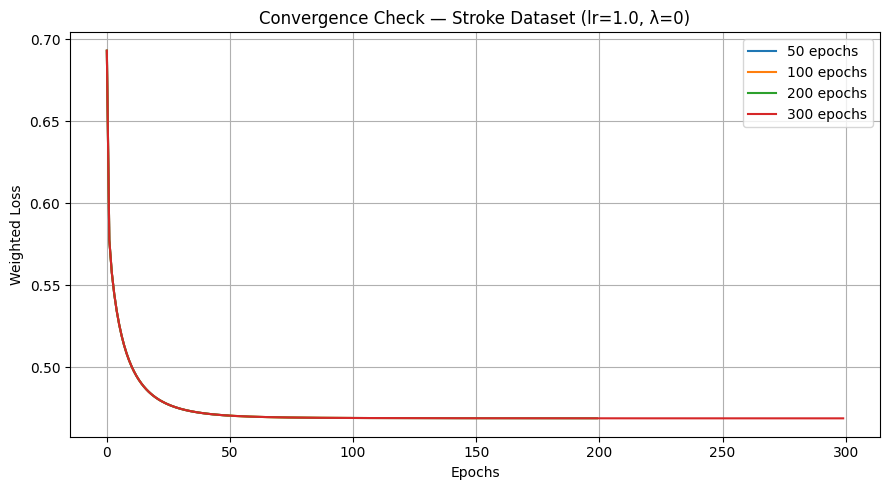

In [12]:
# ============================================================
# Convergence Check — Stroke Dataset
# lr=1.0, lambda=0
# ============================================================

epoch_vals   = [50, 100, 200, 300]
conv_results = {}

for ep in epoch_vals:
  w_ep, b_ep, loss_ep, _ = train_fair_model_weighted(
    X_train_scaled, y_train, A_train, sample_weights,
    lr=1.0,
    epochs=ep,
    lambda_val=0,
    fairness_type=None
  )
  conv_results[ep] = loss_ep
  print(f"Epochs={ep:4d} | Final Loss: {loss_ep[-1]:.4f}")

plt.figure(figsize=(9, 5))
for ep, losses in conv_results.items():
  plt.plot(losses, label=f"{ep} epochs")
plt.xlabel("Epochs")
plt.ylabel("Weighted Loss")
plt.title("Convergence Check — Stroke Dataset (lr=1.0, λ=0)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Fairness Training

In [13]:
# ============================================================
# DP Training — Stroke Dataset
# lr=1.0, epochs=200, weighted loss
# ============================================================

lambda_vals = [0, 0.1, 0.5, 1, 1.5, 2, 2.5, 3, 5, 10]
results_dp  = {}

for lam in lambda_vals:
  print(f"\n=== DP Training with lambda = {lam} ===")

  w, b, loss_hist, dp_hist = train_fair_model_weighted(
    X_train_scaled, y_train, A_train, sample_weights,
    lr=1.0,
    epochs=200,
    lambda_val=lam,
    fairness_type="dp"
  )

  y_prob = predict_proba(X_test_scaled, w, b)
  y_pred = (y_prob >= 0.5).astype(int)

  acc = np.mean(y_pred == y_test)
  auc = roc_auc_score(y_test, y_prob)

  dp_diff, dp_female, dp_male = demographic_parity_difference(
    y_pred, A_test)
  eo_diff, tpr_male, tpr_female = equal_opportunity_difference(
    y_test, y_pred, A_test)

  results_dp[f"lambda={lam}"] = {
    "loss_history": loss_hist,
    "dp_history":   dp_hist,
    "accuracy":     acc,
    "auc":          auc,
    "dp_diff":      dp_diff,
    "dp_male":      dp_male,
    "dp_female":    dp_female,
    "eo_diff":      eo_diff,
    "tpr_male":     tpr_male,
    "tpr_female":   tpr_female,
    "lambda":       lam
  }

  print(f"Acc={acc:.4f} | AUC={auc:.4f} | "
      f"DP={dp_diff:.4f} (M={dp_male:.4f}, F={dp_female:.4f}) | "
      f"EO={eo_diff:.4f} (TPR_M={tpr_male:.4f}, TPR_F={tpr_female:.4f})")


=== DP Training with lambda = 0 ===
Epoch 0: Loss=0.6931, Fairness=0.00000000
Epoch 10: Loss=0.5006, Fairness=0.00004270
Epoch 20: Loss=0.4812, Fairness=0.00006968
Epoch 30: Loss=0.4745, Fairness=0.00008513
Epoch 40: Loss=0.4717, Fairness=0.00009537
Epoch 50: Loss=0.4703, Fairness=0.00010267
Epoch 60: Loss=0.4697, Fairness=0.00010815
Epoch 70: Loss=0.4693, Fairness=0.00011245
Epoch 80: Loss=0.4691, Fairness=0.00011594
Epoch 90: Loss=0.4690, Fairness=0.00011886
Epoch 100: Loss=0.4689, Fairness=0.00012136
Epoch 110: Loss=0.4689, Fairness=0.00012354
Epoch 120: Loss=0.4688, Fairness=0.00012545
Epoch 130: Loss=0.4688, Fairness=0.00012715
Epoch 140: Loss=0.4688, Fairness=0.00012867
Epoch 150: Loss=0.4688, Fairness=0.00013003
Epoch 160: Loss=0.4688, Fairness=0.00013125
Epoch 170: Loss=0.4687, Fairness=0.00013234
Epoch 180: Loss=0.4687, Fairness=0.00013332
Epoch 190: Loss=0.4687, Fairness=0.00013420
Final Epoch 199: Loss=0.4687, Fairness=0.00013491
Acc=0.7299 | AUC=0.8390 | DP=0.0232 (M=0.312

In [14]:
# ============================================================
# EO Training — Stroke Dataset
# lr=1.0, epochs=200, weighted loss
# ============================================================

lambda_vals = [0, 0.1, 0.5, 1, 1.5, 2, 2.5, 3, 5, 10]
results_eo  = {}

for lam in lambda_vals:
  print(f"\n=== EO Training with lambda = {lam} ===")

  w, b, loss_hist, eo_hist = train_fair_model_weighted(
    X_train_scaled, y_train, A_train, sample_weights,
    lr=1.0,
    epochs=200,
    lambda_val=lam,
    fairness_type="eo"
  )

  y_prob = predict_proba(X_test_scaled, w, b)
  y_pred = (y_prob >= 0.5).astype(int)

  acc = np.mean(y_pred == y_test)
  auc = roc_auc_score(y_test, y_prob)

  dp_diff, dp_female, dp_male = demographic_parity_difference(
    y_pred, A_test)
  eo_diff, tpr_male, tpr_female = equal_opportunity_difference(
    y_test, y_pred, A_test)

  results_eo[f"lambda={lam}"] = {
    "loss_history": loss_hist,
    "eo_history":   eo_hist,
    "accuracy":     acc,
    "auc":          auc,
    "dp_diff":      dp_diff,
    "dp_male":      dp_male,
    "dp_female":    dp_female,
    "eo_diff":      eo_diff,
    "tpr_male":     tpr_male,
    "tpr_female":   tpr_female,
    "lambda":       lam
  }

  print(f"Acc={acc:.4f} | AUC={auc:.4f} | "
      f"EO={eo_diff:.4f} (TPR_M={tpr_male:.4f}, TPR_F={tpr_female:.4f}) | "
      f"DP={dp_diff:.4f} (M={dp_male:.4f}, F={dp_female:.4f})")


=== EO Training with lambda = 0 ===
Epoch 0: Loss=0.6931, Fairness=0.00000000
Epoch 10: Loss=0.5006, Fairness=0.00337851
Epoch 20: Loss=0.4812, Fairness=0.00354856
Epoch 30: Loss=0.4745, Fairness=0.00361689
Epoch 40: Loss=0.4717, Fairness=0.00366103
Epoch 50: Loss=0.4703, Fairness=0.00369429
Epoch 60: Loss=0.4697, Fairness=0.00372096
Epoch 70: Loss=0.4693, Fairness=0.00374299
Epoch 80: Loss=0.4691, Fairness=0.00376152
Epoch 90: Loss=0.4690, Fairness=0.00377730
Epoch 100: Loss=0.4689, Fairness=0.00379091
Epoch 110: Loss=0.4689, Fairness=0.00380278
Epoch 120: Loss=0.4688, Fairness=0.00381321
Epoch 130: Loss=0.4688, Fairness=0.00382245
Epoch 140: Loss=0.4688, Fairness=0.00383069
Epoch 150: Loss=0.4688, Fairness=0.00383807
Epoch 160: Loss=0.4688, Fairness=0.00384470
Epoch 170: Loss=0.4687, Fairness=0.00385065
Epoch 180: Loss=0.4687, Fairness=0.00385601
Epoch 190: Loss=0.4687, Fairness=0.00386082
Final Epoch 199: Loss=0.4687, Fairness=0.00386473
Acc=0.7299 | AUC=0.8390 | EO=0.0657 (TPR_M=0

### PLOTS

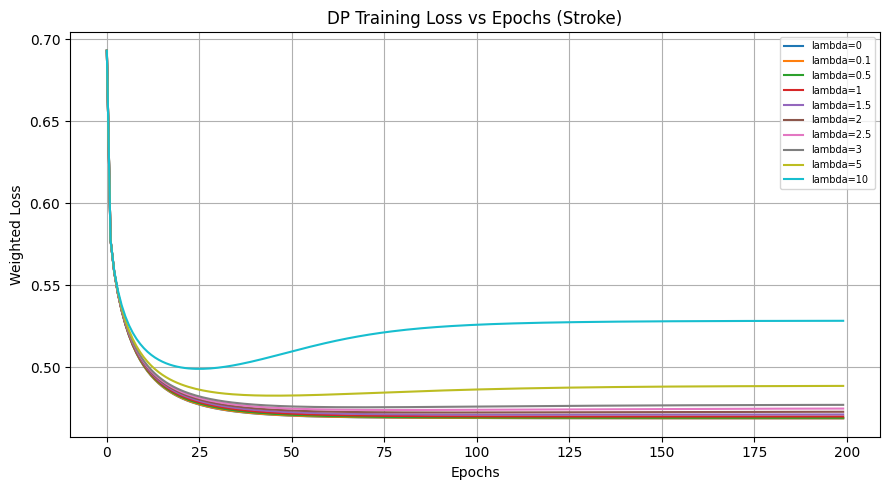

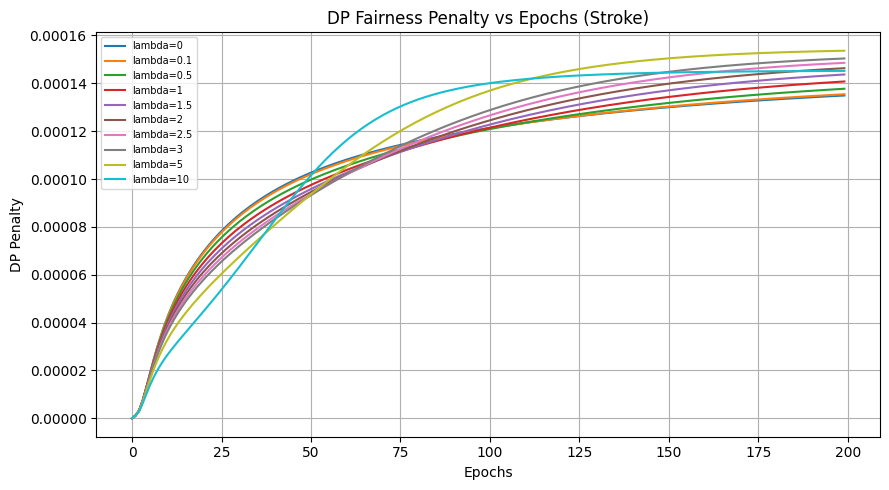

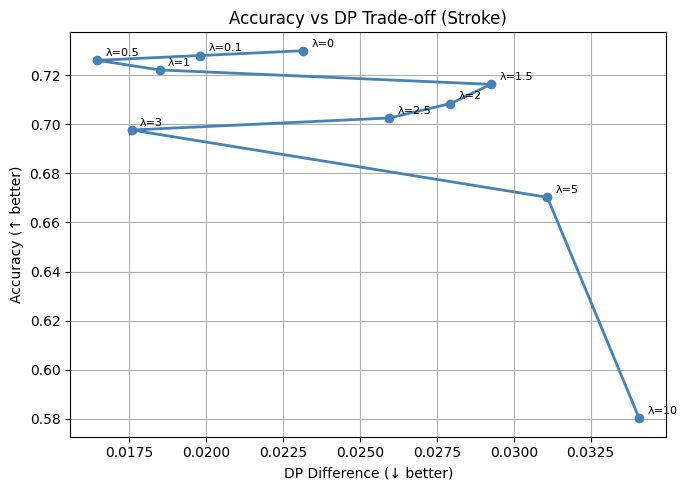

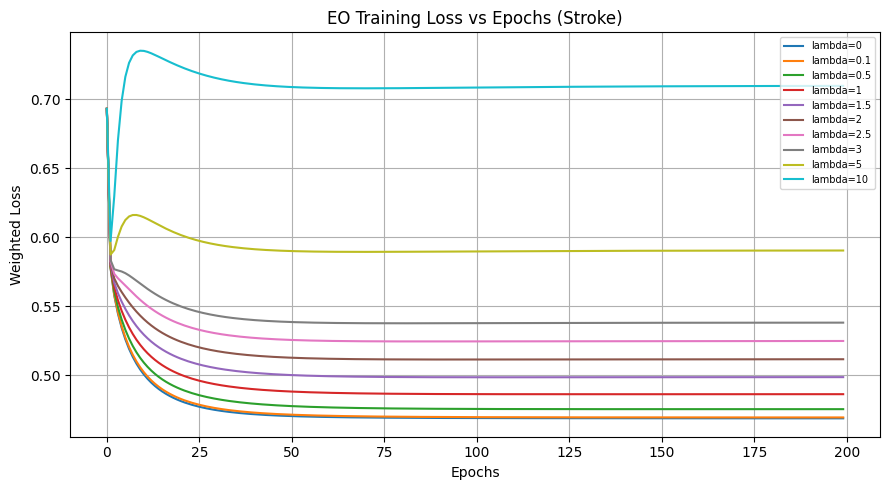

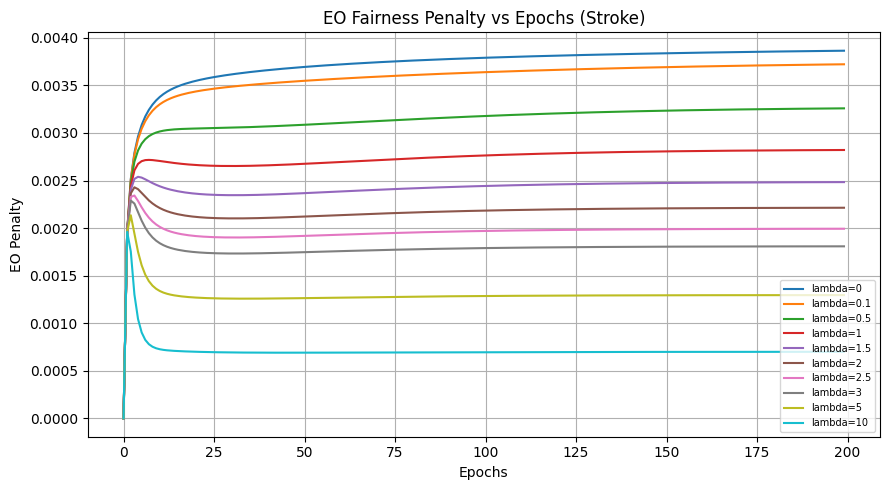

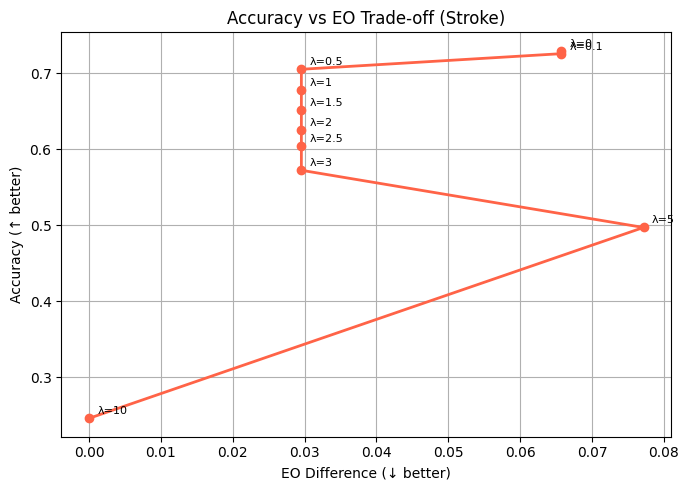

In [15]:
# DP Loss Plot
plt.figure(figsize=(9, 5))
for key, res in results_dp.items():
  plt.plot(res["loss_history"], label=key)
plt.xlabel("Epochs")
plt.ylabel("Weighted Loss")
plt.title("DP Training Loss vs Epochs (Stroke)")
plt.legend(fontsize=7)
plt.grid(True)
plt.tight_layout()
plt.show()

# DP Fairness Penalty Plot
plt.figure(figsize=(9, 5))
for key, res in results_dp.items():
  plt.plot(res["dp_history"], label=key)
plt.xlabel("Epochs")
plt.ylabel("DP Penalty")
plt.title("DP Fairness Penalty vs Epochs (Stroke)")
plt.legend(fontsize=7)
plt.grid(True)
plt.tight_layout()
plt.show()

# DP Trade-off Plot
lambdas = [res["lambda"]   for res in results_dp.values()]
accs    = [res["accuracy"] for res in results_dp.values()]
dps     = [res["dp_diff"]  for res in results_dp.values()]
plt.figure(figsize=(7, 5))
plt.plot(dps, accs, marker='o', color='steelblue', linewidth=2)
for i, lam in enumerate(lambdas):
  plt.annotate(f"λ={lam}", (dps[i], accs[i]),
              textcoords="offset points", xytext=(6, 3), fontsize=8)
plt.xlabel("DP Difference (↓ better)")
plt.ylabel("Accuracy (↑ better)")
plt.title("Accuracy vs DP Trade-off (Stroke)")
plt.grid(True)
plt.tight_layout()
plt.show()

# EO Loss Plot
plt.figure(figsize=(9, 5))
for key, res in results_eo.items():
  plt.plot(res["loss_history"], label=key)
plt.xlabel("Epochs")
plt.ylabel("Weighted Loss")
plt.title("EO Training Loss vs Epochs (Stroke)")
plt.legend(fontsize=7)
plt.grid(True)
plt.tight_layout()
plt.show()

# EO Fairness Penalty Plot
plt.figure(figsize=(9, 5))
for key, res in results_eo.items():
  plt.plot(res["eo_history"], label=key)
plt.xlabel("Epochs")
plt.ylabel("EO Penalty")
plt.title("EO Fairness Penalty vs Epochs (Stroke)")
plt.legend(fontsize=7)
plt.grid(True)
plt.tight_layout()
plt.show()

# EO Trade-off Plot
lambdas = [res["lambda"]   for res in results_eo.values()]
accs    = [res["accuracy"] for res in results_eo.values()]
eos     = [res["eo_diff"]  for res in results_eo.values()]
plt.figure(figsize=(7, 5))
plt.plot(eos, accs, marker='o', color='tomato', linewidth=2)
for i, lam in enumerate(lambdas):
  plt.annotate(f"λ={lam}", (eos[i], accs[i]),
              textcoords="offset points", xytext=(6, 3), fontsize=8)
plt.xlabel("EO Difference (↓ better)")
plt.ylabel("Accuracy (↑ better)")
plt.title("Accuracy vs EO Trade-off (Stroke)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
def compute_adaptive_weights(BRD, PCS):
  """
  Compute adaptive fairness penalty weights based on
  dataset diagnostic properties BRD and PCS.

  BRD weight (for DP): piecewise linear, peaks at high BRD
  PCS weight (for EO): piecewise linear, rises with PCS

  Returns:
      w_BRD: adaptive weight for DP penalty
      w_PCS: adaptive weight for EO penalty
  """

  # DP weight based on BRD
  if BRD < 0.05:
    w_BRD = 0.0      # unnecessary — no real disparity
  elif BRD <= 0.25:
    w_BRD = (BRD - 0.05) / 0.20   # scale linearly
  else:
    w_BRD = 1.0      # full penalty — high disparity

  # EO weight based on PCS
  if PCS < 0.05:
    w_PCS = 0.0      # signal too weak — will be ignored
  elif PCS <= 0.15:
    w_PCS = (PCS - 0.05) / 0.10   # scale linearly
  else:
    w_PCS = 1.0      # full signal — EO can work

  return w_BRD, w_PCS


# Example usage
w_BRD, w_PCS = compute_adaptive_weights(BRD, PCS)

print(f"BRD={BRD:.4f} → DP adaptive weight: {w_BRD:.4f}")
print(f"PCS={PCS:.4f} → EO adaptive weight: {w_PCS:.4f}")
print()
print("Interpretation:")
print(f"  DP penalty will be scaled by {w_BRD:.1%} of λ")
print(f"  EO penalty will be scaled by {w_PCS:.1%} of λ")

BRD=0.0040 → DP adaptive weight: 0.0000
PCS=0.0276 → EO adaptive weight: 0.0000

Interpretation:
  DP penalty will be scaled by 0.0% of λ
  EO penalty will be scaled by 0.0% of λ


In [17]:
# ============================================================
# Adaptive Fairness-Aware Loss Function — Stroke Dataset
# BRD and PCS computed pre-training → adaptive weights
# ============================================================

# Compute adaptive weights
w_BRD, w_PCS = compute_adaptive_weights(BRD, PCS)

# Effective lambda values
lambda_fixed    = 2.0   # standard approach — arbitrary choice
lambda_adap_dp  = lambda_fixed * w_BRD
lambda_adap_eo  = lambda_fixed * w_PCS

print("=" * 50)
print("ADAPTIVE LOSS FUNCTION — STROKE DATASET")
print("=" * 50)
print(f"BRD = {BRD:.4f} → w_BRD = {w_BRD:.4f}")
print(f"PCS = {PCS:.4f} → w_PCS = {w_PCS:.4f}")
print()
print(f"Standard  DP λ = {lambda_fixed}")
print(f"Adaptive  DP λ = {lambda_adap_dp:.4f}")
print()
print(f"Standard  EO λ = {lambda_fixed}")
print(f"Adaptive  EO λ = {lambda_adap_eo:.4f}")
print()
print("Prediction: Adaptive weights reduce penalty to zero.")
print("Expected result: Model stays close to baseline.")
print("This confirms regularization is unnecessary on Stroke.")

ADAPTIVE LOSS FUNCTION — STROKE DATASET
BRD = 0.0040 → w_BRD = 0.0000
PCS = 0.0276 → w_PCS = 0.0000

Standard  DP λ = 2.0
Adaptive  DP λ = 0.0000

Standard  EO λ = 2.0
Adaptive  EO λ = 0.0000

Prediction: Adaptive weights reduce penalty to zero.
Expected result: Model stays close to baseline.
This confirms regularization is unnecessary on Stroke.


In [18]:
# Train adaptive DP model
print("=== Adaptive DP Training ===")
w_dp, b_dp, loss_dp, fair_dp = train_fair_model_weighted(
  X_train_scaled, y_train, A_train, sample_weights,
  lr=1.0,
  epochs=200,
  lambda_val=lambda_adap_dp,
  fairness_type="dp"
)

y_prob_adap_dp = predict_proba(X_test_scaled, w_dp, b_dp)
y_pred_adap_dp = (y_prob_adap_dp >= 0.5).astype(int)

acc_adap_dp = np.mean(y_pred_adap_dp == y_test)
auc_adap_dp = roc_auc_score(y_test, y_prob_adap_dp)
dp_diff_adap, dp_f, dp_m = demographic_parity_difference(
  y_pred_adap_dp, A_test)
eo_diff_adap, tpr_m, tpr_f = equal_opportunity_difference(
  y_test, y_pred_adap_dp, A_test)

print(f"Adaptive DP → Acc={acc_adap_dp:.4f} | AUC={auc_adap_dp:.4f} | "
    f"DP={dp_diff_adap:.4f} | EO={eo_diff_adap:.4f}")

# Train adaptive EO model
print("\n=== Adaptive EO Training ===")
w_eo, b_eo, loss_eo, fair_eo = train_fair_model_weighted(
  X_train_scaled, y_train, A_train, sample_weights,
  lr=1.0,
  epochs=200,
  lambda_val=lambda_adap_eo,
  fairness_type="eo"
)

y_prob_adap_eo = predict_proba(X_test_scaled, w_eo, b_eo)
y_pred_adap_eo = (y_prob_adap_eo >= 0.5).astype(int)

acc_adap_eo = np.mean(y_pred_adap_eo == y_test)
auc_adap_eo = roc_auc_score(y_test, y_prob_adap_eo)
dp_diff_adap_eo, _, _ = demographic_parity_difference(
  y_pred_adap_eo, A_test)
eo_diff_adap_eo, tpr_m_eo, tpr_f_eo = equal_opportunity_difference(
  y_test, y_pred_adap_eo, A_test)

print(f"Adaptive EO → Acc={acc_adap_eo:.4f} | AUC={auc_adap_eo:.4f} | "
    f"DP={dp_diff_adap_eo:.4f} | EO={eo_diff_adap_eo:.4f}")

=== Adaptive DP Training ===
Epoch 0: Loss=0.6931, Fairness=0.00000000
Epoch 10: Loss=0.5006, Fairness=0.00004270
Epoch 20: Loss=0.4812, Fairness=0.00006968
Epoch 30: Loss=0.4745, Fairness=0.00008513
Epoch 40: Loss=0.4717, Fairness=0.00009537
Epoch 50: Loss=0.4703, Fairness=0.00010267
Epoch 60: Loss=0.4697, Fairness=0.00010815
Epoch 70: Loss=0.4693, Fairness=0.00011245
Epoch 80: Loss=0.4691, Fairness=0.00011594
Epoch 90: Loss=0.4690, Fairness=0.00011886
Epoch 100: Loss=0.4689, Fairness=0.00012136
Epoch 110: Loss=0.4689, Fairness=0.00012354
Epoch 120: Loss=0.4688, Fairness=0.00012545
Epoch 130: Loss=0.4688, Fairness=0.00012715
Epoch 140: Loss=0.4688, Fairness=0.00012867
Epoch 150: Loss=0.4688, Fairness=0.00013003
Epoch 160: Loss=0.4688, Fairness=0.00013125
Epoch 170: Loss=0.4687, Fairness=0.00013234
Epoch 180: Loss=0.4687, Fairness=0.00013332
Epoch 190: Loss=0.4687, Fairness=0.00013420
Final Epoch 199: Loss=0.4687, Fairness=0.00013491
Adaptive DP → Acc=0.7299 | AUC=0.8390 | DP=0.0232 | 

In [19]:
# ============================================================
# Comparison Table — Baseline vs Standard vs Adaptive
# ============================================================

print("=" * 70)
print("STROKE DATASET — COMPLETE COMPARISON TABLE")
print("=" * 70)
print(f"{'Model':<25} {'Acc':>7} {'AUC':>7} {'DP Diff':>9} {'EO Diff':>9}")
print("-" * 70)

# Baseline (λ=0) — pull from results_dp
baseline = results_dp["lambda=0"]
print(f"{'Baseline (λ=0)':<25} "
    f"{baseline['accuracy']:>7.4f} "
    f"{baseline['auc']:>7.4f} "
    f"{baseline['dp_diff']:>9.4f} "
    f"{baseline['eo_diff']:>9.4f}")

# Standard DP (λ=2)
std_dp = results_dp["lambda=2"]
print(f"{'Standard DP (λ=2)':<25} "
    f"{std_dp['accuracy']:>7.4f} "
    f"{std_dp['auc']:>7.4f} "
    f"{std_dp['dp_diff']:>9.4f} "
    f"{std_dp['eo_diff']:>9.4f}")

# Adaptive DP
print(f"{'Adaptive DP (λ×w_BRD)':<25} "
    f"{acc_adap_dp:>7.4f} "
    f"{auc_adap_dp:>7.4f} "
    f"{dp_diff_adap:>9.4f} "
    f"{eo_diff_adap:>9.4f}")

# Standard EO (λ=2)
std_eo = results_eo["lambda=2"]
print(f"{'Standard EO (λ=2)':<25} "
    f"{std_eo['accuracy']:>7.4f} "
    f"{std_eo['auc']:>7.4f} "
    f"{std_eo['dp_diff']:>9.4f} "
    f"{std_eo['eo_diff']:>9.4f}")

# Adaptive EO
print(f"{'Adaptive EO (λ×w_PCS)':<25} "
    f"{acc_adap_eo:>7.4f} "
    f"{auc_adap_eo:>7.4f} "
    f"{dp_diff_adap_eo:>9.4f} "
    f"{eo_diff_adap_eo:>9.4f}")

print("=" * 70)
print()
print("Key insight: Adaptive weights = 0 on Stroke → model unchanged.")
print("This CONFIRMS the diagnostic prediction: regularization unnecessary.")
print(f"Standard DP (λ=2) accuracy loss vs baseline: "
    f"{baseline['accuracy'] - std_dp['accuracy']:.4f}")
print(f"Adaptive DP accuracy loss vs baseline: "
    f"{baseline['accuracy'] - acc_adap_dp:.4f}")

STROKE DATASET — COMPLETE COMPARISON TABLE
Model                         Acc     AUC   DP Diff   EO Diff
----------------------------------------------------------------------
Baseline (λ=0)             0.7299  0.8390    0.0232    0.0657
Standard DP (λ=2)          0.7084  0.8400    0.0279    0.0296
Adaptive DP (λ×w_BRD)      0.7299  0.8390    0.0232    0.0657
Standard EO (λ=2)          0.6252  0.8395    0.0386    0.0296
Adaptive EO (λ×w_PCS)      0.7299  0.8390    0.0232    0.0657

Key insight: Adaptive weights = 0 on Stroke → model unchanged.
This CONFIRMS the diagnostic prediction: regularization unnecessary.
Standard DP (λ=2) accuracy loss vs baseline: 0.0215
Adaptive DP accuracy loss vs baseline: 0.0000
